Figure 2 and 3

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyextremes import EVA
import pyextremes




In [2]:
infile = r'/Users/jackywong1105/Desktop/Project 1/Monsoon Rainfall/4078832.csv'
df = pd.read_csv(infile,usecols=['NAME','LATITUDE','LONGITUDE','ELEVATION','DATE','PRCP'],parse_dates=['DATE'])

In [3]:
stations = df[['NAME','LATITUDE','LONGITUDE','ELEVATION']]
stations = stations.drop_duplicates().reset_index(drop=True)

Loop through each unique station by NAME

52.86


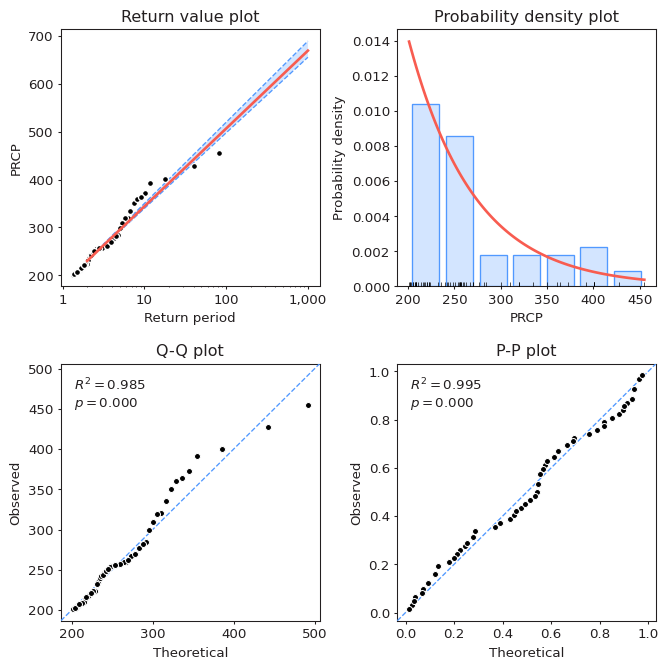

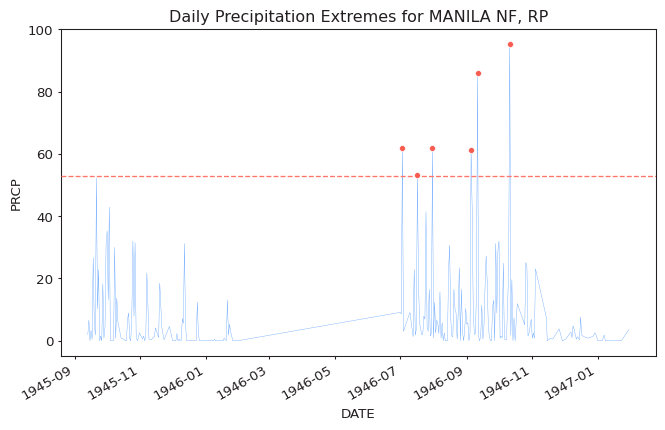

64.8


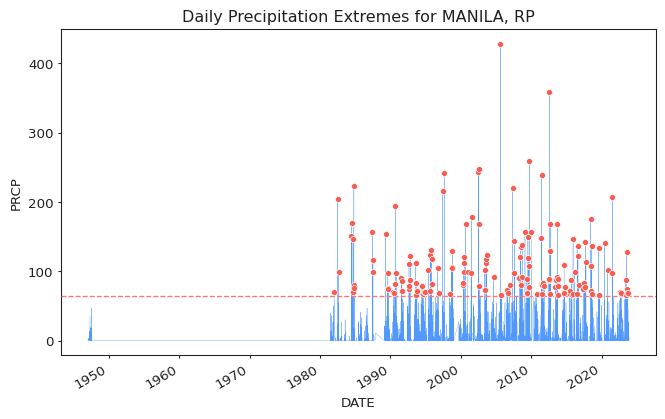

52.86


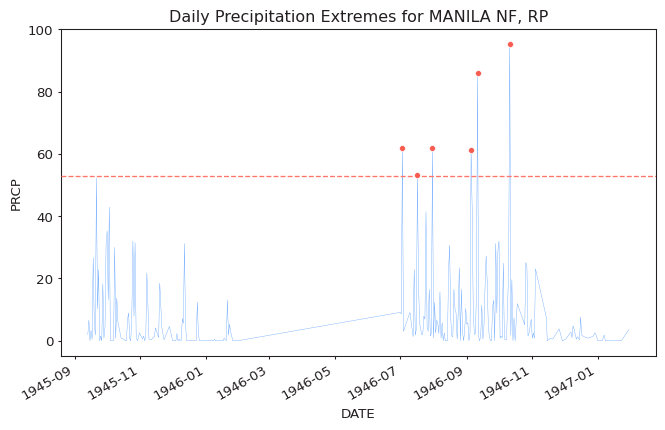

50.5


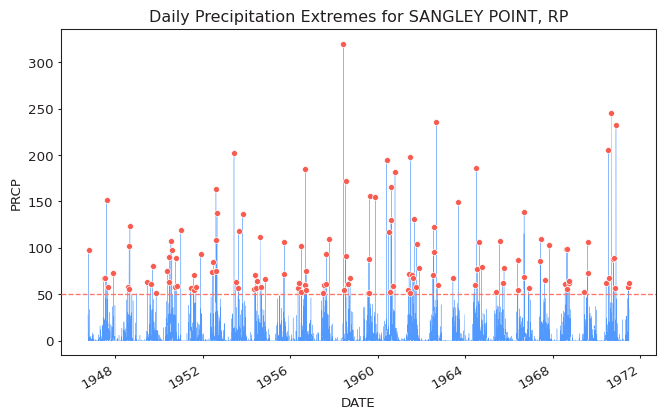

68.8


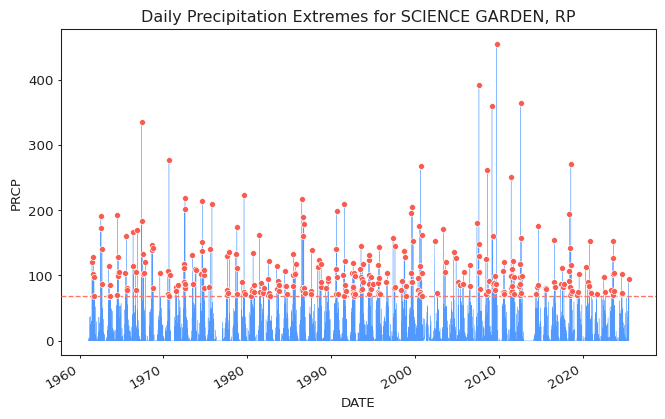

50.0


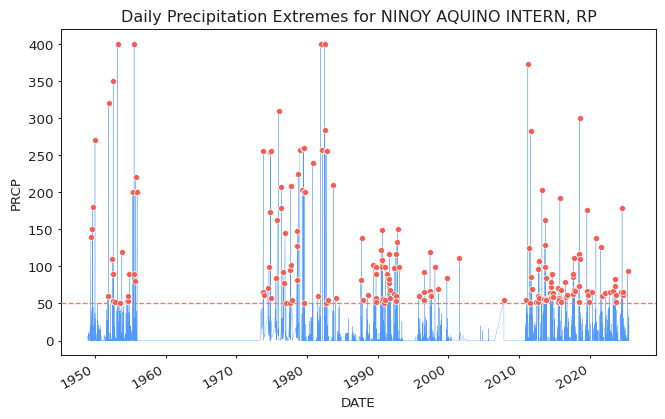

In [30]:
# Loop through each unique station by NAME
for idx, station in stations.iterrows():
    station_name = station['NAME']
    
    # Filter data for the current station
    data = df[df['NAME'] == station_name].copy()
    data = data[['DATE', 'PRCP']].dropna(subset=['PRCP']).set_index('DATE')
    data = data.sort_index(ascending=True)
    series = data.squeeze()
    
    # Initialize EVA model
    model = EVA(series)
    
    # Set threshold at 98th percentile
    threshold = np.percentile(series, 98)
    print(threshold)
    model.get_extremes(method='POT', threshold=threshold)
    
    # Plot the time series with the 98th percentile threshold
    model.plot_extremes()
    plt.title(f"Daily Precipitation Extremes for {station_name}")
    
    # Save the plot
    safe_station_name = station_name.replace(" ", "_").replace(",", "")
    plt.savefig(f"extremes_{safe_station_name}.png", dpi=300, bbox_inches="tight")
    
    # Show the plot
    plt.show()
    
    # Close the plot to free memory
    plt.close()

manually do it by each station

In [6]:
stations

,NAME,LATITUDE,LONGITUDE,ELEVATION
0,"MANILA NF, RP",14.60000,121.00000,33.2
1,"MANILA, RP",14.55000,120.98333,4.3
2,"MANILA NF, RP",14.60000,121.00000,4.3
3,"SANGLEY POINT, RP",14.49472,120.91138,2.1
4,"SCIENCE GARDEN, RP",14.63300,121.01700,46.0
5,"NINOY AQUINO INTERN, RP",14.51700,121.00000,15.0


In [7]:
data = df[df.NAME == stations.loc[5,'NAME']].copy()
data = data[['DATE','PRCP']].dropna(subset='PRCP').set_index('DATE')
data = data.sort_index(ascending=True)
series = data.squeeze()

In [8]:
data

,PRCP
DATE,
1949-01-09,1.0
1949-01-10,6.1
1949-01-11,0.0
1949-02-16,10.9
1949-02-17,0.0
...,...
2025-07-11,0.0
2025-07-12,2.0
2025-07-13,2.0


In [9]:
series

DATE
1949-01-09     1.0
1949-01-10     6.1
1949-01-11     0.0
1949-02-16    10.9
1949-02-17     0.0
              ... 
2025-07-11     0.0
2025-07-12     2.0
2025-07-13     2.0
2025-07-14     0.0
2025-07-19    42.4
Name: PRCP, Length: 11328, dtype: float64

In [10]:
model = EVA(series)

threshold = np.percentile(series, 98)
model.get_extremes(method='POT', threshold=threshold)


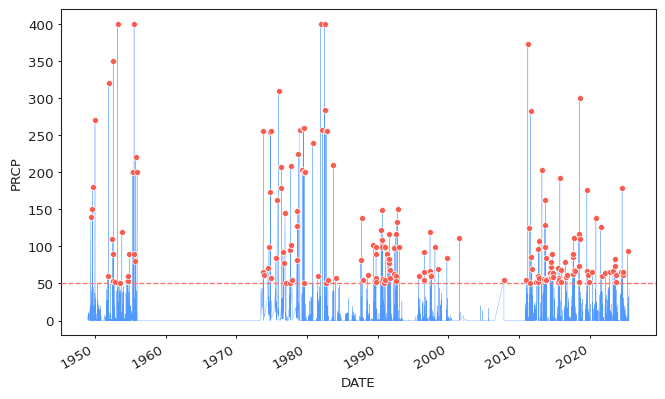

In [11]:
# Plot the time series with the 98th percentile threshold
model.plot_extremes()
plt.show()

get the max rainfall out of five stations each day

In [4]:
# Load the CSV file
df = pd.read_csv("4078832.csv", usecols=['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'DATE', 'PRCP'], parse_dates=['DATE'])
df

,STATION,NAME,LATITUDE,LONGITUDE,DATE,PRCP
0,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-01,9.1
1,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-02,8.6
2,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-03,62.0
3,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-04,3.0
4,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-05,NaN
...,...,...,...,...,...,...
72020,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-15,NaN
72021,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-16,NaN
72022,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-17,NaN
72023,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-18,NaN


In [5]:
# Extract unique stations based on LATITUDE and LONGITUDE, excluding duplicate MANILA NF, RP
stations = df[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE']].drop_duplicates(subset=['LATITUDE', 'LONGITUDE']).reset_index(drop=True)
# Ensure only 5 stations by excluding one if necessary (e.g., keeping first 5 unique coordinates)
print("Number of unique stations (based on LATITUDE and LONGITUDE):", len(stations))
print(stations[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE']])


Number of unique stations (based on LATITUDE and LONGITUDE): 5
       STATION                     NAME  LATITUDE  LONGITUDE
0  RPW00041228            MANILA NF, RP  14.60000  121.00000
1  RPW00041229               MANILA, RP  14.55000  120.98333
2  RPW00041224        SANGLEY POINT, RP  14.49472  120.91138
3  RP000098430       SCIENCE GARDEN, RP  14.63300  121.01700
4  RP000098429  NINOY AQUINO INTERN, RP  14.51700  121.00000


In [6]:
# Filter data for the selected stations
selected_names = stations['NAME'].tolist()
data = df[df['NAME'].isin(selected_names)].copy()
data


,STATION,NAME,LATITUDE,LONGITUDE,DATE,PRCP
0,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-01,9.1
1,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-02,8.6
2,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-03,62.0
3,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-04,3.0
4,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-05,NaN
...,...,...,...,...,...,...
72020,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-15,NaN
72021,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-16,NaN
72022,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-17,NaN
72023,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-18,NaN


In [7]:
# Compute daily maximum rainfall across the five stations
daily_max = data.groupby('DATE')['PRCP'].max().reset_index().dropna(subset=['PRCP']).set_index('DATE').sort_index(ascending=True)
series = daily_max.squeeze()


77.0


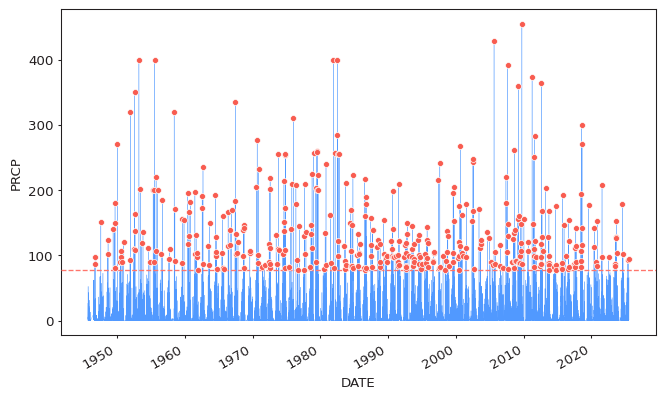

In [134]:
# Initialize EVA model from pyextremes
model = EVA(series)

# Calculate the 98th percentile threshold
threshold = np.percentile(series, 98)
print(threshold)
model.get_extremes(method='POT', threshold=threshold)

# Plot the time series with the 98th percentile threshold
model.plot_extremes()

# Save the plot
plt.savefig("daily_max_rainfall_five_stations.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyextremes/eva.py:1251: RuntimeWarning: divide by zero encountered in divide
  exceedance_probability = 1 / return_period / extremes_rate
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


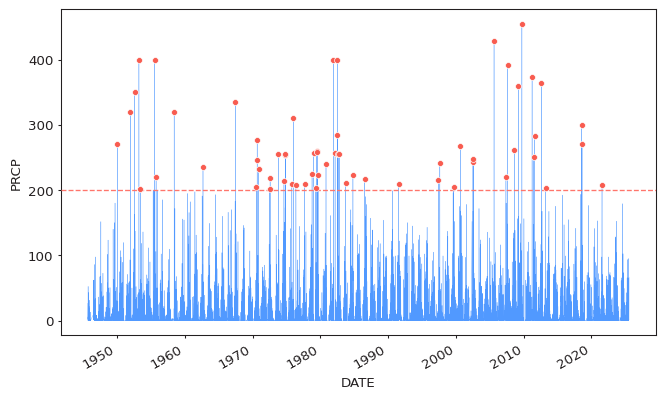

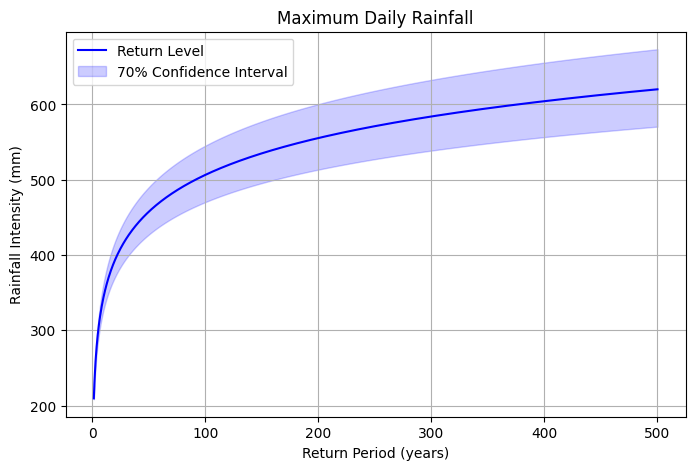

Exceedance Summary for Key Return Periods:
               return value    lower ci    upper ci
return period                                      
0.0                    -inf         NaN         NaN
2.0              229.958061  228.442889  231.459855
5.0              294.715782  289.925397  299.463874
10.0             343.703106  336.435118  350.906928
25.0             408.460827  397.917625  418.910947
50.0             457.448152  444.427346  470.354001
100.0            506.435477  490.937068  521.797056
250.0            571.193198  552.419575  589.801075
500.0            620.180522  598.929296  641.244129


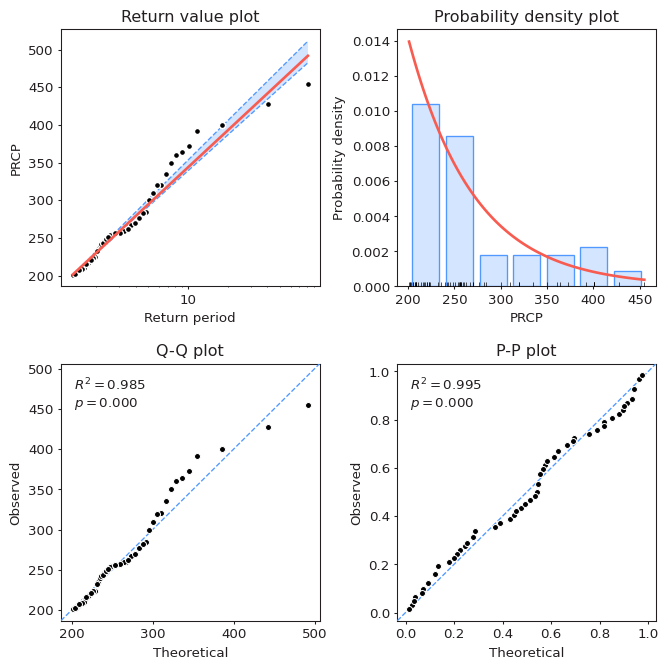

In [ ]:
# Initialize EVA model from pyextremes
model = EVA(series)

model.get_extremes(method='POT', threshold=200)

model.plot_extremes()

# Fit the extreme value model (Generalized Pareto Distribution for POT)
model.fit_model()

# Define return periods 
return_periods = np.linspace(0, 500, 1000)

summary = model.get_summary(return_period=return_periods, alpha=0.7, n_samples=1000)

# Plot exceedance probability (return level vs return period)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(return_periods, summary['return value'], label='Return Level', color='blue')
ax.fill_between(return_periods, summary['lower ci'], summary['upper ci'], color='blue', alpha=0.2, label='70% Confidence Interval')
ax.set_xlabel('Return Period (years)')
ax.set_ylabel('Rainfall Intensity (mm)')
ax.set_title('Maximum Daily Rainfall')
ax.legend()
ax.grid(True)

# Save the plot
# plt.savefig("exceedance_probability_plot_zero_500_90ci.png", dpi=300, )

# Show the plot
plt.show()

# Print summary for key return periods
key_rps = [0, 2, 5, 10, 25, 50, 100, 250, 500]
summary_key = model.get_summary(return_period=key_rps, alpha=0.3, n_samples=1000)
print("Exceedance Summary for Key Return Periods:")
print(summary_key)

# Generate diagnostic plot to verify model fit
model.plot_diagnostic(alpha=0.3)
plt.savefig("diagnostic_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Figure 4 and 5

In [4]:
# Load the CSV file
df = pd.read_csv("4078832.csv", usecols=['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'DATE', 'PRCP'], parse_dates=['DATE'])


In [5]:
df

,STATION,NAME,LATITUDE,LONGITUDE,DATE,PRCP
0,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-01,9.1
1,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-02,8.6
2,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-03,62.0
3,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-04,3.0
4,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-05,NaN
...,...,...,...,...,...,...
72020,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-15,NaN
72021,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-16,NaN
72022,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-17,NaN
72023,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-18,NaN


In [6]:
# Extract unique stations based on LATITUDE and LONGITUDE, excluding duplicate MANILA NF, RP
stations = df[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE']].drop_duplicates(subset=['LATITUDE', 'LONGITUDE']).reset_index(drop=True)


In [7]:
print("Number of unique stations (based on LATITUDE and LONGITUDE):", len(stations))
print(stations[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE']])


Number of unique stations (based on LATITUDE and LONGITUDE): 5
       STATION                     NAME  LATITUDE  LONGITUDE
0  RPW00041228            MANILA NF, RP  14.60000  121.00000
1  RPW00041229               MANILA, RP  14.55000  120.98333
2  RPW00041224        SANGLEY POINT, RP  14.49472  120.91138
3  RP000098430       SCIENCE GARDEN, RP  14.63300  121.01700
4  RP000098429  NINOY AQUINO INTERN, RP  14.51700  121.00000


In [8]:
# Filter data for the selected stations
selected_names = stations['NAME'].tolist()
selected_names
data = df[df['NAME'].isin(selected_names)].copy()
data


,STATION,NAME,LATITUDE,LONGITUDE,DATE,PRCP
0,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-01,9.1
1,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-02,8.6
2,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-03,62.0
3,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-04,3.0
4,RPW00041228,"MANILA NF, RP",14.600,121.0,1946-07-05,NaN
...,...,...,...,...,...,...
72020,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-15,NaN
72021,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-16,NaN
72022,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-17,NaN
72023,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,2025-07-18,NaN


In [9]:
# Compute 5-day moving sum for each station
data = data.pivot(columns='NAME', values='PRCP', index='DATE').fillna(0)  # Pivot to have stations as columns, fill NaN with 0
data.to_csv("test1.csv")

In [10]:
five_day_sum = data.rolling(window='5D', min_periods=1).sum()  # Compute 5-day moving sum for each station
five_day_sum.to_csv("test2.csv")

In [11]:
# Compute maximum 5-day rainfall across stations for each date
daily_max_five_day = five_day_sum.max(axis=1).dropna().sort_index(ascending=True)
series = daily_max_five_day  # Already a Series with DATE index
series.to_csv("test3.csv")
# series_filtered = series.loc['2018-01-01':'2019-12-31']
# series_filtered.to_csv("test3.csv")



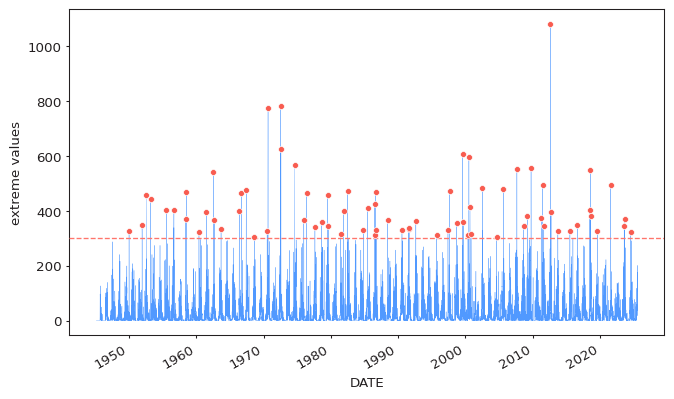

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyextremes/eva.py:1251: RuntimeWarning: divide by zero encountered in divide
  exceedance_probability = 1 / return_period / extremes_rate
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


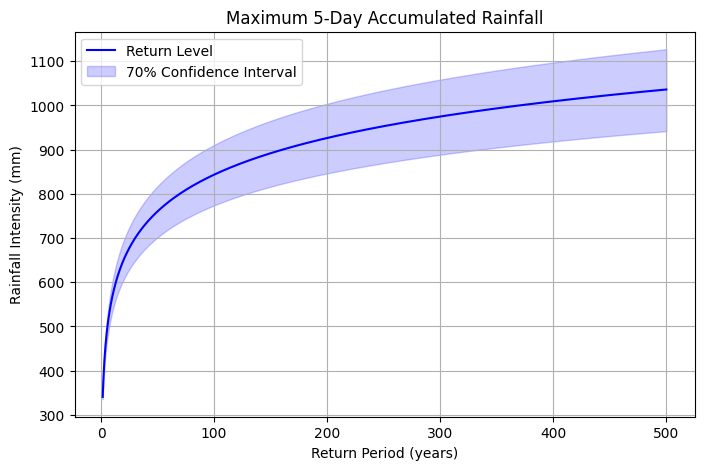

Exceedance Summary for Key Return Periods:
               return value    lower ci     upper ci
return period                                       
0.0                    -inf         NaN          NaN
2.0              374.730574  370.836264   377.646545
5.0              484.499760  474.885230   491.698902
10.0             567.536944  553.595235   577.976179
25.0             677.306131  657.644201   692.028536
50.0             760.343314  736.354206   778.305813
100.0            843.380498  815.064210   864.583091
250.0            953.149684  919.113177   978.635447
500.0           1036.186868  997.823181  1064.912725


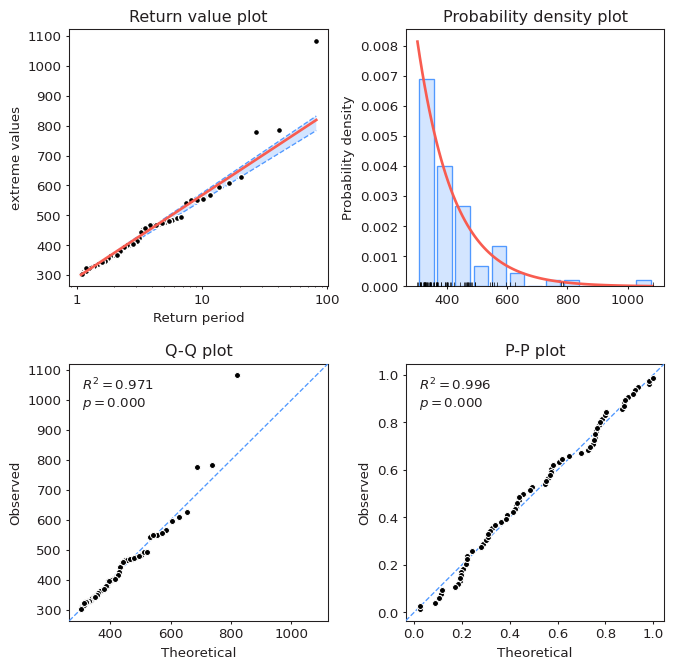

In [12]:
# Initialize EVA model from pyextremes
model = EVA(series)

# Calculate the 98th percentile threshold
#threshold = np.percentile(series, 98)
#print(threshold)

# Get extremes using POT with a 5-day declustering period
model.get_extremes(method='POT', extremes_type='high', threshold=300, r='120h')

# Plot the time series with the 98th percentile threshold
model.plot_extremes()

# Save the plot
plt.savefig("five_day_max_rainfall_timeseries.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

# Fit the extreme value model (Generalized Pareto Distribution for POT)
model.fit_model()

# Define return periods 
return_periods = np.linspace(0, 500, 1000)

# Get return levels with 70% confidence interval
summary = model.get_summary(return_period=return_periods, alpha=0.7, n_samples=1000)

# Plot exceedance probability (return level vs return period)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(return_periods, summary['return value'], label='Return Level', color='blue')
ax.fill_between(return_periods, summary['lower ci'], summary['upper ci'], color='blue', alpha=0.2, label='70% Confidence Interval')
ax.set_xlabel('Return Period (years)')
ax.set_ylabel('Rainfall Intensity (mm)')
ax.set_title('Maximum 5-Day Accumulated Rainfall')
ax.legend()
ax.grid(True)

# Save the plot
plt.savefig("5exceedance_probability_plot_zero_500_90ci.png", dpi=300, )

# Show the plot
plt.show()

# Print summary for key return periods
key_rps = [0, 2, 5, 10, 25, 50, 100, 250, 500]
summary_key = model.get_summary(return_period=key_rps, alpha=0.3, n_samples=1000)
print("Exceedance Summary for Key Return Periods:")
print(summary_key)

# Generate diagnostic plot to verify model fit
model.plot_diagnostic(alpha=0.3)
plt.savefig("diagnostic_plot.png", dpi=300, bbox_inches="tight")
plt.show()